In [7]:
import os
import cv2
import matplotlib.pyplot as plt

# 实现函数: 根据视频帧, 均匀间隔读取 5 帧, 拼接成一长张图片, 注意图片尺寸根据视频不同,保持一样的比例
def get_video_frames(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)

    # 获取视频的总帧数
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 计算每隔多少帧取一帧
    interval = total_frames // num_frames

    frames = []
    for i in range(num_frames):
        # 设置视频的当前帧位置
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        ret, frame = cap.read()
        # if ret:
        #     # 裁剪掉左右两边10%
        #     h, w, _ = frame.shape
        #     left = int(w * 0.125)  # 左边10%
        #     right = int(w * 0.87)  # 右边90%
        #     cropped_frame = frame[:, left:right]  # 裁剪
        #     frames.append(cropped_frame)
        frames.append(frame)

    cap.release()

    if len(frames) > 0:
        return cv2.hconcat(frames)
    else:
        return None
    

def video_frames_show_ori(video_path, num_frames=5):
    video_frames = get_video_frames(video_path, num_frames)

    # 显示视频帧
    plt.figure(figsize=(24, 8))
    plt.imshow(cv2.cvtColor(video_frames, cv2.COLOR_BGR2RGB))
    plt.axis('off')  # 不显示坐标轴
    plt.show()


from zhipuai import ZhipuAI
from IPython.display import Markdown, display

# 不要一行输出reason, 自动换行
def printmd(string):
    display(Markdown(string))



client_ = ZhipuAI(api_key="1768c1961bbb4e16ae4fcbbb17aa7d95.zDLsxB8LdnEcFm6b")


def zhipuai_translate(client, text):
    response = client.chat.completions.create(
        model="GLM-4-Flash-250414",  # 填写需要调用的模型编码
        messages=[
            {"role": "system", "content": "你是一个擅长中英互译的助手，你的任务是为用户执行准确地的翻译。"},
            {"role": "user", "content": text}
        ],
    )
    
    return response.choices[0].message.content

In [ ]:
from tqdm import tqdm
import pandas as pd
from openai import OpenAI
tqdm.pandas()

client = OpenAI(
    # 若没有配置环境变量，请用百炼API Key将下行替换为：api_key="sk-xxx",
    api_key="sk-d9ba1d233187457bb1ec65da245055ef",
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)


def func_prompt_template(reason):
    prompt = f"""Please assume the role of an expert in the field of emotions. \
We provide clues that may be related to the emotions of the characters. Based on the provided clues, please identify the emotional states of the main character. \
The main character is the one with the most detailed clues. \
Please separate different emotional categories with commas and output only the clearly identifiable emotional categories in a list format. \
If none are identified, please output an empty list. \
Input: We cannot recognize his emotional state; Output: [] \
Input: His emotional state is happy, sad, and angry; Output: [happy, sad, angry] \
Input: {reason}; Output: """
    return prompt


def qwen_plus_2025_04_28_reason(client, reason):

    question = func_prompt_template(reason)
    
    printmd(question)
    
    completion = client.chat.completions.create(
        # 模型列表：https://help.aliyun.com/zh/model-studio/getting-started/models
        # model = "qwen-plus-latest",
        model = "qwen-plus-2025-04-28",

        messages=[
            {"role": "system", "content": ""},
            {"role": "user", "content": question},
        ],
        # Qwen3模型通过enable_thinking参数控制思考过程（开源版默认True，商业版默认False）
        # 使用Qwen3开源版模型时，若未启用流式输出，请将下行取消注释，否则会报错
        # extra_body={"enable_thinking": True,}
    )

    return completion.choices[0].message.content

In [ ]:
import os
import numpy as np
import pandas as pd
from IPython.display import Markdown, clear_output, display, Video, Audio

msa_video_path = '/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3'
msa_audio_path = '/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3'

file_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000005_loss_0.952.npz'
data = np.load(file_path, allow_pickle=True)
# 获取 name2reason 字典
name2reason_dict = data['name2reason'].item()
keys_list = list(name2reason_dict.keys())
print(len(data['name2reason'].item()))
print(data['name2reason'].item(0).keys())


# 将 name2reason_dict 转换为 CSV 文件
output_csv_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/track3_mercaptionplus.csv'

# 将字典转换为 DataFrame
name2reason_df = pd.DataFrame(list(name2reason_dict.items()), columns=['name', 'reason'])

# 保存为 CSV 文件
name2reason_df.to_csv(output_csv_path, index=False)

print(f"CSV 文件已保存至: {output_csv_path}")
# name2reason_dict

In [ ]:
# 遍历name2reason_df，查看reason是否与name2reason_dict中的reason一致
output_csv_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/track3_mercaptionplus.csv'
reason_csv = pd.read_csv(output_csv_path)
# 遍历name2reason_df，查看reason是否与name2reason_dict中的reason一致

num = 0
for idx, row in reason_csv.iterrows():
    name = row['name']
    reason = name2reason_dict[name]
    reason_csv_item_reason = row['reason']

    if reason_csv_item_reason == reason:
        num += 1

    if reason_csv_item_reason != reason:
        printmd(name)
        printmd(reason)
        printmd(reason_csv_item_reason)
        print(reason_csv_item_reason == reason)

print(f"共有 {num} 个 name 与 reason 一致")

In [ ]:
path_track2_moban = '/disk3/MER-2025/MER2025_Track23/output/answer_track2_moban.csv'
path_track3_moban = '/disk3/MER-2025/MER2025_Track23/output/answer_track3_moban.csv'

track3_moban = pd.read_csv(path_track3_moban)

for idx, row in track3_moban.iterrows():
    name_track3_moban = track3_moban['name'][idx]
    name_track3 = reason_csv['name'][idx]
    if name_track3_moban != name_track3:
        printmd(name_track3_moban)
        printmd(name_track3)
        printmd(f"Row {idx} has different name in track3_moban and reason_csv: {name_track3_moban} vs {name_track3}")

# 处理

In [ ]:
import re
import pandas as pd

track3_reson_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/track3_mercaptionplus.csv'
track3_reson = pd.read_csv(track3_reson_path)

# 打印列名和样本数量
print(track3_reson.columns)
print(len(track3_reson))

# 定义函数计算中文字符比例
def chinese_char_ratio(text):
    if not isinstance(text, str):
        return 0
    chinese_chars = re.findall(r'[\u4e00-\u9fff]', text)
    return len(chinese_chars) / len(text) if len(text) > 0 else 0

# 找出中文字符比例超过10%的样本
threshold = 0.1
track3_reson['chinese_ratio'] = track3_reson['reason'].apply(chinese_char_ratio)
filtered_samples = track3_reson[track3_reson['chinese_ratio'] > threshold]

for idx, row in filtered_samples.iterrows():
    name = row['name']
    reason = row['reason']
    printmd(f"Name: {name}")
    printmd(f"Reason: {reason}")

In [ ]:
# 输出reason列 的值中最长的前10个
track3_reson['reason_length'] = track3_reson['reason'].apply(lambda x: len(x))
longest_reasons = track3_reson.nlargest(0, 'reason_length')
for idx, row in longest_reasons.iterrows():
    reason_value = row['reason']
    name_value = row['name']
    printmd(name_value)
    printmd(reason_value)
    # printmd(f"Row {idx} has reason: {reason_value}")
    # printmd(f"Row {idx} has name: {name_value}")
    # printmd(f"Row {idx} has reason length: {len(reason_value)}")

In [ ]:
import pandas as pd
import re

# 读取数据
ovmerd_path = '/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/track2_train_ovmerd.csv'
ovmerd = pd.read_csv(ovmerd_path)

# 打印列名和样本数量
print(ovmerd.columns)
print(len(ovmerd))
print(ovmerd.head())

# 自定义解析函数
def parse_emotions(emotions):
    if not isinstance(emotions, str):
        return []
    # 去除多余的字符并尝试解析为列表
    emotions = re.sub(r'[^\w,]', '', emotions)  # 去除非字母、数字和逗号的字符
    return [e.strip() for e in emotions.split(',') if e.strip()]  # 按逗号分割并去除空白

# 收集 openset 列中的情绪词集合
openset_samples = []
for emotions in ovmerd['openset']:
    try:
        emotion_list = parse_emotions(emotions)
        openset_samples.extend(emotion_list)
    except Exception as e:
        print(f"无法解析的内容: {emotions}, 错误: {e}")

# 去重并排序
unique_emotions = sorted(set(openset_samples))

# 打印结果
print("情绪词集合：", unique_emotions)
print("情绪词数量：", len(unique_emotions))

In [ ]:
import pandas as pd
from tqdm import tqdm
import pandas as pd
from openai import OpenAI
tqdm.pandas()

client = OpenAI(
    # 若没有配置环境变量，请用百炼API Key将下行替换为：api_key="sk-xxx",
    api_key="sk-d9ba1d233187457bb1ec65da245055ef",
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)



def func_prompt_template2(reason):
    prompt = f"""Please assume the role of an expert in the field of emotions. \
We provide clues that may be related to the emotions of the characters. Based on the provided clues, please identify the emotional states of the main character. \
The main character is the one with the most detailed clues. \
Please separate different emotional categories with commas and output only the clearly identifiable emotional categories in a list format. \
If none are identified, please output an empty list. \
Input: We cannot recognize his emotional state; Output: [] \
Input: His emotional state is happy, sad, and angry; Output: [happy, sad, angry] \
Input: {reason}; Output: """
    return prompt



def qwen_plus_2025_04_28_reason(client, reason):

    question = func_prompt_template(reason)
    
    # printmd(question)
    
    completion = client.chat.completions.create(
        # 模型列表：https://help.aliyun.com/zh/model-studio/getting-started/models
        # model = "qwen-plus-latest",
        model = "qwen-plus-2025-04-28",

        messages=[
            {"role": "system", "content": ""},
            {"role": "user", "content": question},
        ],
        # Qwen3模型通过enable_thinking参数控制思考过程（开源版默认True，商业版默认False）
        # 使用Qwen3开源版模型时，若未启用流式输出，请将下行取消注释，否则会报错
        # extra_body={"enable_thinking": True,}
    )

    return completion.choices[0].message.content



track3_reson_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/track3_mercaptionplus.csv'
track3_reson = pd.read_csv(track3_reson_path)


# 创建包含 name,openset 2列的pd, 命名为track2_openset
track2_openset = pd.DataFrame(columns=['name', 'openset'])

# 遍历track3_reson['reason'] 提取情感状态
for idx, row in tqdm(track3_reson.iterrows(), total=len(track3_reson)):
    name = row['name']
    reason = row['reason']
    
    # 调用 qwen_plus_2025_04_28_reason 函数获取情感状态
    while True:
        emotion_states = qwen_plus_2025_04_28_reason(client, reason)
        if not any('\u4e00' <= char <= '\u9fff' for char in emotion_states):
            break
    emotion_states = emotion_states.strip('[]')

    # 将结果添加到 track2_openset DataFrame
    new_row = pd.DataFrame({'name': [name], 'openset': [emotion_states]})
    track2_openset = pd.concat([track2_openset, new_row], ignore_index=True)
    
    if idx == 20:
        break

# track2_openset.to_csv('/disk3/MER-2025/MER2025_Track23/output/track2_openset.csv', index=False)
track2_openset.head(5)

In [ ]:
name = 'samplenew3_00066081'
reason = name2reason_dict[name]
idx = keys_list.index(name)

printmd(f"**Name:** {name}\n\n**Reason:** {reason}")
printmd(zhipuai_translate(client_, reason))

video_path = f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/video/{name}.mp4'
audio_path = f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/audio/{name}.wav'

openset_npz_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000025_loss_0.133-openset.npz'
data_openset = np.load('/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000025_loss_0.133-openset.npz', allow_pickle=True)
# 加载npz文件
with np.load(openset_npz_path, allow_pickle=True) as data:
    # 获取filenames和fileitems数组
    filenames = data['filenames']
    fileitems = data['fileitems']

data_openset_csv = pd.read_csv('/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000025_loss_0.133-openset.csv')

name_npz = filenames[idx]
npz_openset = fileitems[idx]

name_csv = data_openset_csv.iloc[idx]['name']
csv_openset = data_openset_csv.iloc[idx]['openset']

print(f"**Name (npz):** {name_npz}\n\n**Openset (npz):** {npz_openset}\n\n**Name (csv):** {name_csv}\n\n**Openset (csv):** {csv_openset}")

# 显示视频
video_frames_show(video_path, 5)
display(Video(video_path, width=480, height=300))

In [ ]:
import numpy as np
import pandas as pd

openset_npz_path = '/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000025_loss_0.133-openset.npz'
data_openset = np.load('/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000025_loss_0.133-openset.npz', allow_pickle=True)
# 加载npz文件
with np.load(openset_npz_path, allow_pickle=True) as data:
    # 获取filenames和fileitems数组
    filenames = data['filenames']
    fileitems = data['fileitems']

data_openset_csv = pd.read_csv('/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/checkpoint_000025_loss_0.133-openset.csv')

idx = 4
name = filenames[idx]
npz_openset = fileitems[idx]
csv_openset = data_openset_csv.iloc[idx]['openset']

print(f"**Name:** {name}\n\n**Openset (npz):** {npz_openset}\n\n**Openset (csv):** {csv_openset}")

In [ ]:
from IPython.display import Markdown, clear_output, display, Video, Audio

name = 'samplenew3_00009931'

       
reason = '''
       In the text, the subtitle says, "It should be divided equally." This sentence may be an individual's suggestion or request regarding a certain issue or situation. Based on the description of the individual's high-pitched and excited tone in the audio clue, as well as the individual's fast speech rate, it suggests that they may be feeling anxious or nervous. We can infer that this sentence may carry a sense of urgency or anxiety, expressing the individual's dissatisfaction or concern about some unfair or unequal situation. Therefore, this sentence may be the individual's way of expressing complaint or dissatisfaction, consistent with the overall display of anxiety and stress by the individual.
'''
printmd(f"**Name:** {name}\n\n**Reason:** {reason}")
printmd(zhipuai_translate(client_, reason))

video_path = f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/video/{name}.mp4'
audio_path = f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/audio/{name}.wav'

# 显示视频
video_frames_show(video_path, 5)
display(Video(video_path, width=480, height=300))
# display(Audio(audio_path))

In [4]:
def get_video_frames_list(video_path, num_frames=8):
    """
    从视频中均匀间隔读取指定数量的帧，返回帧列表
    """
    cap = cv2.VideoCapture(video_path)

    # 获取视频的总帧数
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 计算每隔多少帧取一帧
    interval = total_frames // num_frames

    frames = []
    for i in range(num_frames):
        # 设置视频的当前帧位置
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)

    cap.release()
    return frames

def video_frames_show(video_path, num_frames=8):
    """
    显示成两张图，每张图显示一半的帧
    """
    frames = get_video_frames_list(video_path, num_frames)
    
    if not frames:
        print("无法从视频中读取帧")
        return

    # 将帧分成两组
    mid_point = len(frames) // 2
    frames_group1 = frames[:mid_point]
    frames_group2 = frames[mid_point:]
    
    # 显示第一组帧
    if frames_group1:
        combined_frame1 = cv2.hconcat(frames_group1)
        plt.figure(figsize=(12, 4))
        plt.imshow(cv2.cvtColor(combined_frame1, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    
    # 显示第二组帧
    if frames_group2:
        combined_frame2 = cv2.hconcat(frames_group2)
        plt.figure(figsize=(12, 4))
        plt.imshow(cv2.cvtColor(combined_frame2, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

In [18]:
def get_video_frames_list(video_path, num_frames=8):
    """
    从视频中均匀间隔读取指定数量的帧，返回帧列表
    """
    cap = cv2.VideoCapture(video_path)

    # 获取视频的总帧数
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 计算每隔多少帧取一帧
    interval = total_frames // num_frames

    frames = []
    for i in range(num_frames):
        # 设置视频的当前帧位置
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)

    cap.release()
    return frames

def video_frames_show(video_path, num_frames=8):
    """
    显示成两张图，每张图显示一半的帧
    """
    frames = get_video_frames_list(video_path, num_frames)
    
    if not frames:
        print("无法从视频中读取帧")
        return

    # 将帧分成两组
    mid_point = len(frames) // 2
    frames_group1 = frames[:mid_point]
    frames_group2 = frames[mid_point:]
    
    # 显示第一组帧
    if frames_group1:
        combined_frame1 = cv2.hconcat(frames_group1)
        plt.figure(figsize=(12, 4))
        plt.imshow(cv2.cvtColor(combined_frame1, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    
    # 显示第二组帧
    if frames_group2:
        combined_frame2 = cv2.hconcat(frames_group2)
        plt.figure(figsize=(12, 4))
        plt.imshow(cv2.cvtColor(combined_frame2, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

In [2]:
import random
import pandas as pd
from IPython.display import Markdown, clear_output, display, Video, Audio

msa_reason_csv = pd.read_csv('/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/track3_msa.csv')
mer_reason_csv = pd.read_csv('/disk3/MER-2025/MER2025_Track23/output/results-description-mer2025ov/msa_outputhybird_bestsetup_bestfusion_frame_lz_20250705141/track3_mercaptionplus.csv')

17684


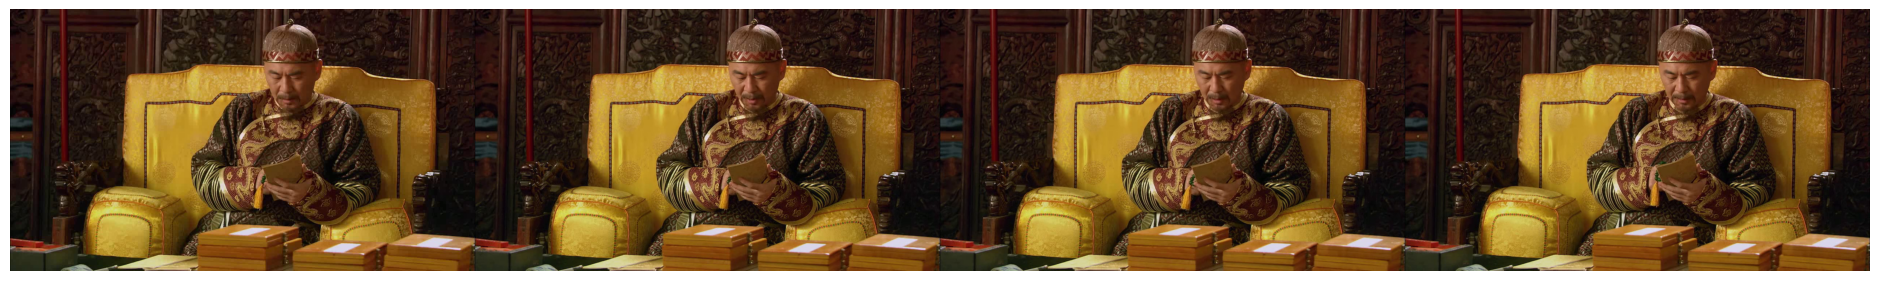

**Name:** samplenew3_00022109

**Reason:** In the video, the screen shows a man sitting on a throne-like chair, wearing elaborate clothing, resembling a king or emperor. The background is decorated with a red curtain and various treasures, indicating a royal setting. At the beginning of the video, his gaze is downward, with a slight frown, suggesting a serious or contemplative expression. His mouth moves slightly, indicating that he may be engaged in a serious conversation or decision-making process. As time passes, his gaze shifts to the left, with no significant changes in his facial expression, suggesting he may be thinking or reflecting. In the audio, the tone is low and measured, reinforcing a sense of solemnity or introspection. In the text, the subtitle reads, "I am well aware of the ambitions of the Mongolian Khan." This sentence reflects a restrained acknowledgment of a strategic or political concern. Based on the video clues of the man's elaborate clothing, throne-like chair, and decorative background, it can be inferred that this sentence is spoken by a king or emperor in a royal context. The man's initial expression and subtle movements suggest that he is thoughtfully addressing a matter of strategic or political significance. Therefore, this sentence may be the king or emperor expressing his awareness of the Mongolian Khan’s ambitions, possibly in a context of conflict, power, or strategic concern.

**Name:** samplenew3_00022109

**Reason:** In the text, caption content: "I am fully aware of the aspirations of the Mongol Khan." This sentence might be a man describing or evaluate a certain situation or topic. Given that the man appears calm and serene in the video hints, with his body posture and facial expression showing no signs of anxiety or agitation, we can infer that this sentence might be spoken in a cool and composed manner. Therefore, this sentence may not express strong emotions, but rather a way of description or evaluation, in line with the man's's overall calm and composed emotional state.

In [89]:
index = random.randint(0, len(msa_reason_csv) - 1)
name = msa_reason_csv.loc[index, 'name']
print(index)


video_frames_show_ori(f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/video/{name}.mp4', 4)
# display(Video(f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/video/{name}.mp4', width=480, height=300))
display(Audio(f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/audio/{name}.wav'))


mas_reason = msa_reason_csv.loc[index, 'reason']
printmd(f"**Name:** {name}\n\n**Reason:** {mas_reason}")
# printmd(zhipuai_translate(client_, mas_reason))


mer_reason = mer_reason_csv.loc[index, 'reason']
printmd(f"**Name:** {name}\n\n**Reason:** {mer_reason}")
# printmd(zhipuai_translate(client_, mer_reason))

In [90]:
# name = 'samplenew3_00102040'

# video_frames_show(f'/disk3/Datasets/zengyb/Datasets/MER2025_data/track1_3/video/{name}.mp4', 10)


msa_index = msa_reason_csv[msa_reason_csv['name'] == name].index[0]
mas_reason = msa_reason_csv.loc[msa_index, 'reason']
printmd(f"**Name:** {name}\n\n**Reason:** {mas_reason}")
printmd(zhipuai_translate(client_, mas_reason))


mer_index = mer_reason_csv[mer_reason_csv['name'] == name].index[0]
mer_reason = mer_reason_csv.loc[mer_index, 'reason']
printmd(f"**Name:** {name}\n\n**Reason:** {mer_reason}")
printmd(zhipuai_translate(client_, mer_reason))

**Name:** samplenew3_00022109

**Reason:** In the video, the screen shows a man sitting on a throne-like chair, wearing elaborate clothing, resembling a king or emperor. The background is decorated with a red curtain and various treasures, indicating a royal setting. At the beginning of the video, his gaze is downward, with a slight frown, suggesting a serious or contemplative expression. His mouth moves slightly, indicating that he may be engaged in a serious conversation or decision-making process. As time passes, his gaze shifts to the left, with no significant changes in his facial expression, suggesting he may be thinking or reflecting. In the audio, the tone is low and measured, reinforcing a sense of solemnity or introspection. In the text, the subtitle reads, "I am well aware of the ambitions of the Mongolian Khan." This sentence reflects a restrained acknowledgment of a strategic or political concern. Based on the video clues of the man's elaborate clothing, throne-like chair, and decorative background, it can be inferred that this sentence is spoken by a king or emperor in a royal context. The man's initial expression and subtle movements suggest that he is thoughtfully addressing a matter of strategic or political significance. Therefore, this sentence may be the king or emperor expressing his awareness of the Mongolian Khan’s ambitions, possibly in a context of conflict, power, or strategic concern.

在视频中，屏幕显示一位坐在王座式椅子上、身着华丽服饰的男子，他看起来像是一位国王或皇帝。背景装饰着红色的帷幕和各式珍宝，暗示这是一个皇家场景。视频开始时，他的目光向下，眉头微蹙，表现出严肃或沉思的表情。他的嘴唇轻微移动，表明他可能正在进行严肃的对话或决策过程。随着时间的推移，他的目光转向左边，面部表情没有明显变化，表明他可能在思考或反思。音频中的语调低沉而平稳，强化了庄重或内省的氛围。字幕中写道：“我清楚地知道蒙古可汗的野心。”这句话反映了对战略或政治问题的克制承认。根据视频中男子华丽的服饰、王座式椅子和装饰背景的线索，可以推断这句话是由一位国王或皇帝在皇家环境中说出的。男子的初始表情和细微动作表明他在认真处理一件战略或政治上的重要事务。因此，这句话可能是国王或皇帝表达他对蒙古可汗野心的认识，可能是在冲突、权力或战略问题的背景下。

**Name:** samplenew3_00022109

**Reason:** In the text, caption content: "I am fully aware of the aspirations of the Mongol Khan." This sentence might be a man describing or evaluate a certain situation or topic. Given that the man appears calm and serene in the video hints, with his body posture and facial expression showing no signs of anxiety or agitation, we can infer that this sentence might be spoken in a cool and composed manner. Therefore, this sentence may not express strong emotions, but rather a way of description or evaluation, in line with the man's's overall calm and composed emotional state.

在文本中，标题内容：“我完全了解蒙古可汗的抱负。”这句话可能是某个人在描述或评价某个特定情况或主题。鉴于该男子在视频线索中显得平静而安详，他的身体姿态和面部表情没有任何焦虑或烦躁的迹象，我们可以推断这句话可能是以一种冷静和从容的方式说出的。因此，这句话可能不会表达强烈的情感，而更可能是描述或评价的方式，这与该男子整体的平静和从容的情绪状态相一致。